# Project Dataset : "Auto Price Prediction"
Domain: Auto Mobile

# Problem Statement

The objective of this project is to develop a machine learning regression model that predicts the selling price of automobiles based on their technical specifications and features.

The dataset contains information such as company name, fuel type, body style, engine size, horsepower, curb weight, mileage, and other automobile attributes.

This project includes data cleaning, handling missing values, exploratory data analysis, categorical data encoding, training multiple regression models, and evaluating their performance using appropriate metrics.

The best-performing model will be selected to estimate the price of new automobiles.

# Project building Path :

1. Import Libraries
2. Load Dataset
3. Understand Dataset
4. Data Cleaning
5. Handle Missing Values
6. Exploratory Data Analysis (EDA)
7. Separate X and y
8. Encode Categorical Variables
9. Train-Test Split
11. Train Multiple Regression Models
12. Evaluate Models
13. Actual vs Predicted Analysis
14. Model Performance Comparison
15. Select Final Model & Save 

# Import Libraries :

In [49]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,r2_score


# Load Dataset :

In [50]:
df=pd.read_csv(r"D:\datasets\Internship_Projects\Auto_Mobile_Price_Data\auto_imports.csv")
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


# Understand Dataset :

In [51]:
columns = [
    "Symboling", "Normalized-Losses","Company-name","Fuel-type","Aspiration","Num-of-doors",
    "Body-style","Drive-wheels","Engine-location","Wheel-base","Length","Width","Height","Curb-weight",
    "Engine-type","Num-of-cylinders","Engine-size","Fuel-system","Bore","Stroke","Compression-ratio",
    "Horsepower","Peak-rpm","City-mpg","Highway-mpg","Price"]

In [52]:
df = pd.read_csv(r"D:\datasets\Internship_Projects\Auto_Mobile_Price_Data\auto_imports.csv",
                 names=columns,na_values="?")
df.head()

,Symboling,Normalized-Losses,Company-name,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,...,Engine-size,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


# Explanation :
        > Load my CSV
        > Give it the correct Columan names
        > Convert ? into Missing values
        > Save everything as "df"."

In [53]:
df.shape

(201, 26)

> Rows : 201
> Columns : 26

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Symboling          201 non-null    int64  
 1   Normalized-Losses  164 non-null    float64
 2   Company-name       201 non-null    str    
 3   Fuel-type          201 non-null    str    
 4   Aspiration         201 non-null    str    
 5   Num-of-doors       199 non-null    str    
 6   Body-style         201 non-null    str    
 7   Drive-wheels       201 non-null    str    
 8   Engine-location    201 non-null    str    
 9   Wheel-base         201 non-null    float64
 10  Length             201 non-null    float64
 11  Width              201 non-null    float64
 12  Height             201 non-null    float64
 13  Curb-weight        201 non-null    int64  
 14  Engine-type        201 non-null    str    
 15  Num-of-cylinders   201 non-null    str    
 16  Engine-size        201 non-null    in

In [55]:
df.describe(include="all")

,Symboling,Normalized-Losses,Company-name,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,...,Engine-size,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price
count,201.000000,164.000000,201,201,201,199,201,201,201,201.000000,...,201.000000,201,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
unique,NaN,NaN,22,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,181,165,113,94,118,198,NaN,...,NaN,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.840796,122.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.797015,...,126.875622,NaN,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,35.442168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.066366,...,41.546834,NaN,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,98.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000


# Data Cleaning :

# Missing Values
Missing values are imputed later inside the ML pipeline (after the train/test split)
so that no information from the test set leaks into training.

In [56]:
df.isnull().sum()[df.isnull().sum()>0]

Normalized-Losses    37
Num-of-doors          2
Bore                  4
Stroke                4
Horsepower            2
Peak-rpm              2
dtype: int64

#  Handle Missing Values :

In [57]:
df["Normalized-Losses"]=    df["Normalized-Losses"].fillna(df["Normalized-Losses"].mean())
df["Num-of-doors"]     =    df["Num-of-doors"].fillna(df["Num-of-doors"].mode()[0])
df["Bore"]             =    df["Bore"].fillna(df["Bore"].mean())
df["Stroke"]           =    df["Stroke"].fillna(df["Stroke"].mean())
df["Horsepower"]       =    df["Horsepower"].fillna(df["Horsepower"].mean())
df["Peak-rpm"]         =    df["Peak-rpm"].fillna(df["Peak-rpm"].mean())

In [58]:
print("Total Null Values:", df.isnull().sum().sum())

Total Null Values: 0


# EDA (Exploratory Data Analysis) :

# Heatmap :  "Correlation of Features"

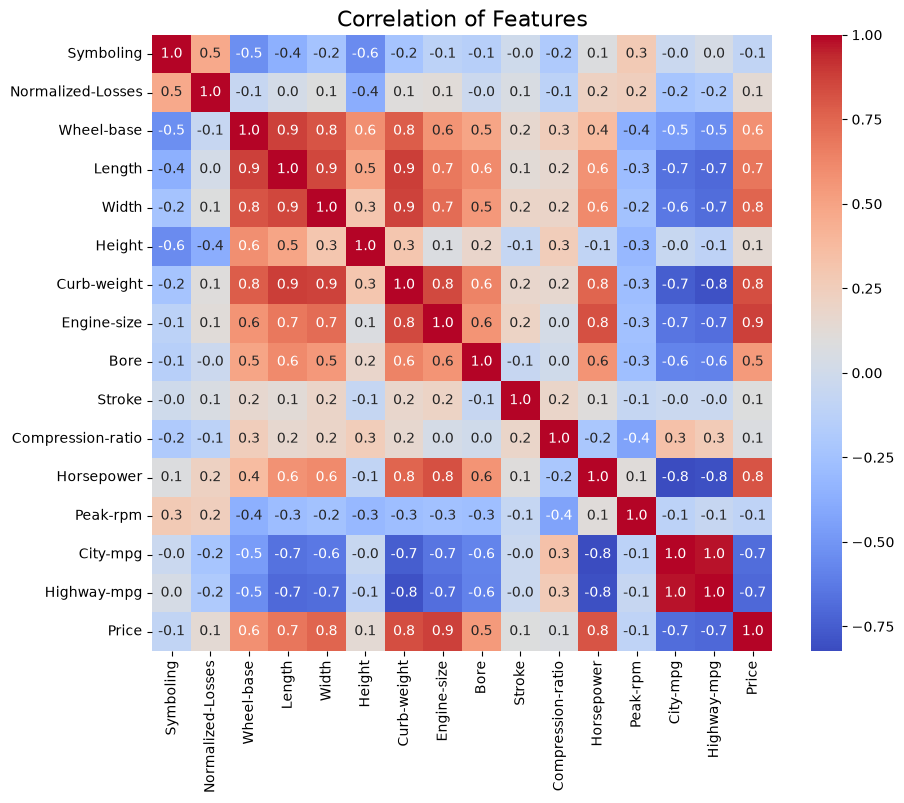

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Correlation of Features", fontsize=16)

plt.show()

# Explanation :

A heatmap is a color chart that shows how strongly different numbers are related to each other.

* It helps see which features are strongly connected to price.
Example: engine size, curb weight, and horsepower usually have a strong relationship with price.

# Target Variable(Sales Price) Analysis :

# Histogram : "Distribution of Cars Sales Price"

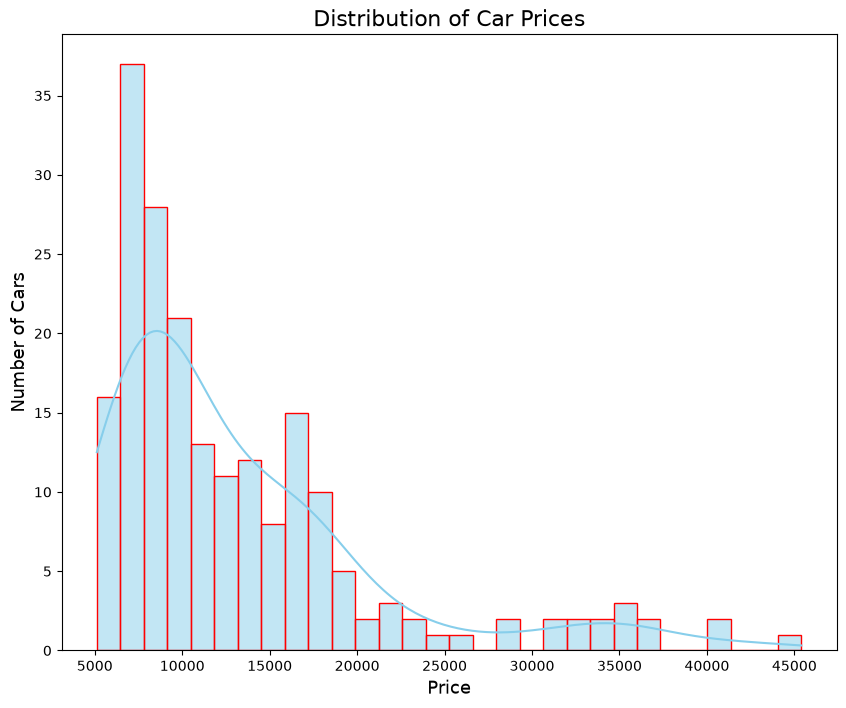

In [60]:
plt.figure(figsize=(10,8))

sns.histplot(
    data=df,
    x="Price",
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="red"
)

plt.title("Distribution of Car Prices",fontsize=16)
plt.xlabel("Price",fontsize=13)
plt.ylabel("Number of Cars",fontsize=13)

plt.show()

# Explanation :
        "This graph shows how many cars fall into different price ranges. The Price Distribution helps us understand the overall spread of automobile prices and identify skewmess and potential extreme values."

* Important Info:

- Most Cars Price -> Between 5000-20000 Price Range
- Few Cars Price -> Very Expensive Range

"Price is right-skewed, so the target is log-transformed during training to stabilise errors."

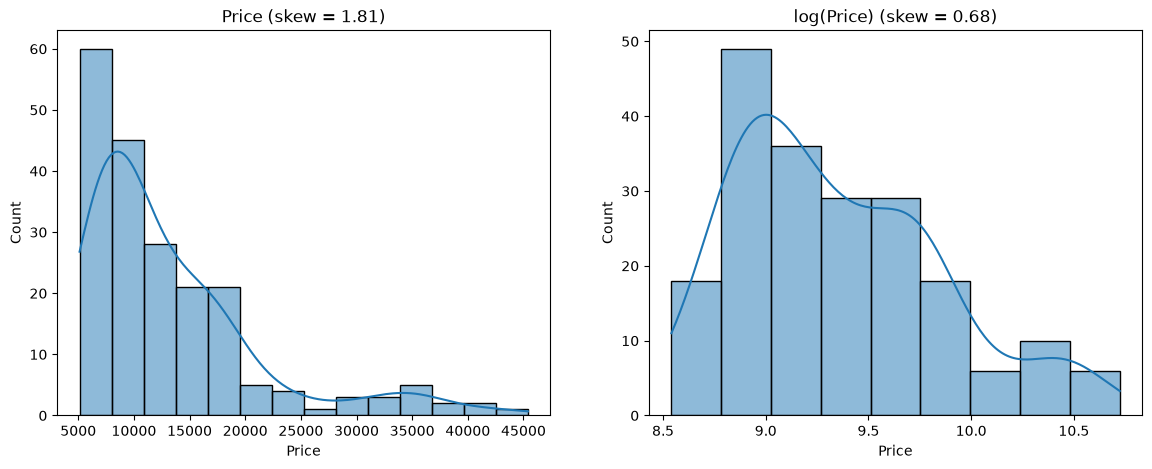

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df["Price"], kde=True, ax=ax[0]).set_title(f"Price (skew = {df['Price'].skew():.2f})")
sns.histplot(np.log1p(df["Price"]), kde=True, ax=ax[1]).set_title(f"log(Price) (skew = {np.log1p(df['Price']).skew():.2f})")
plt.show()

# Boxplot : "Outlier Detection of Price"

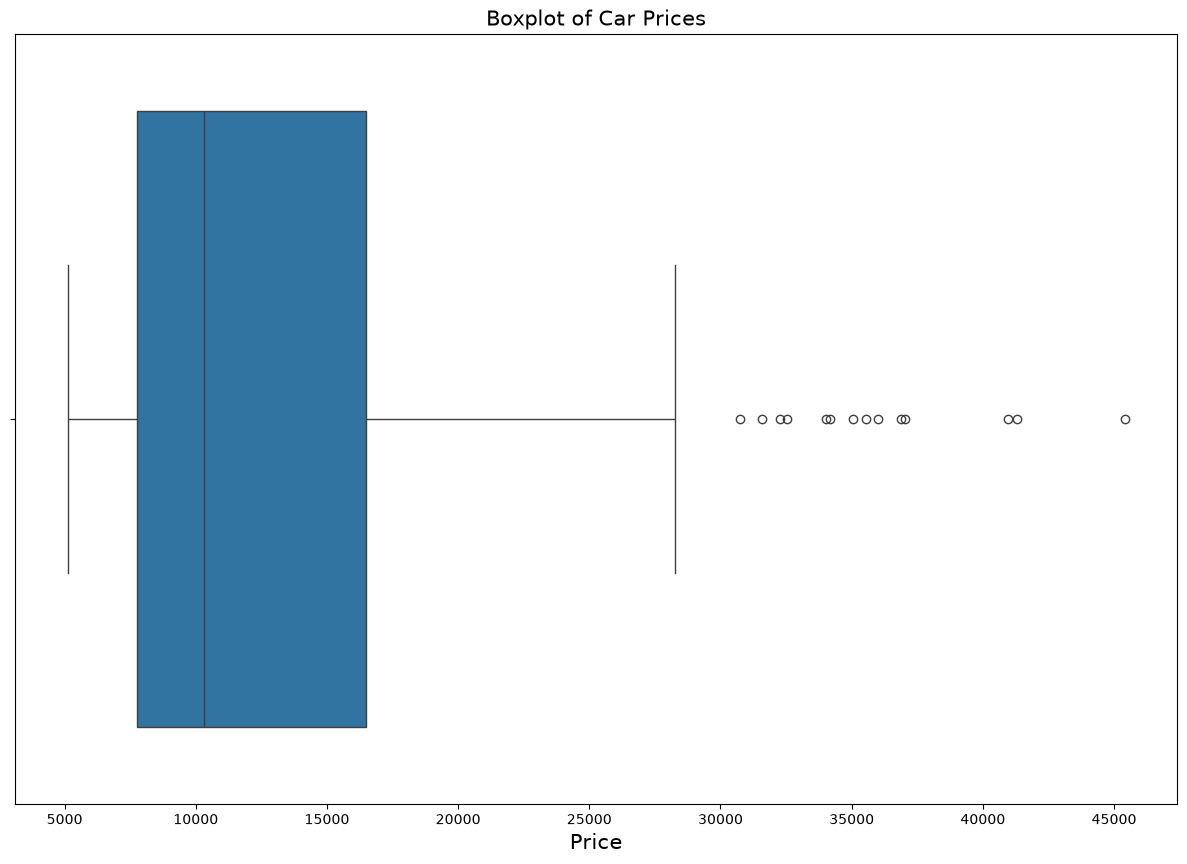

In [62]:
plt.figure(figsize=(15,10))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Car Prices",fontsize=15)
plt.xlabel("Price",fontsize=15)

plt.show()

# Explanation :
        "The Boxplot helps identify unusually high or low prices.
                In Our Dataset Mostly Car Prices range in between from 5000 to 30000 but some few cars are expensive may be their are Luxury Cars which More than Price Range."

# Car Company vs Price :

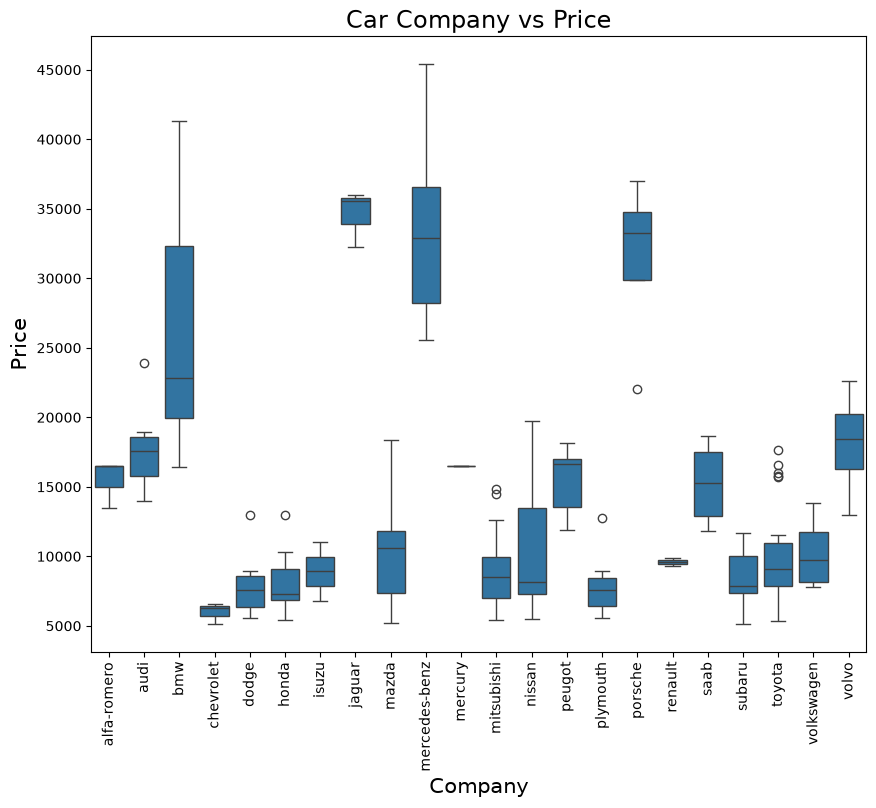

In [63]:
plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x="Company-name",
    y="Price"
)

plt.xticks(rotation=90)

plt.title("Car Company vs Price",fontsize=17)
plt.xlabel("Company",fontsize=15)
plt.ylabel("Price",fontsize=15)

plt.show()

# Explanation :
        "This compares prices of different automobile companies."

Importatnt Info :

* Companies with Generally Lower Prices : "Chevrolet, Dodge, Honda, Isuzu, Mazda, Mitsubishi, Nissan, Plymouth, Renault, Subaru, Toyota, Volkswagen"

* Companies with Generally Higher Prices : "Alfa-Romero, Audi, BMW, Jaguar, Mercedes-benz, Mercury, Peugot, Saab, Volvo"

# Scatterplot : "Engine Size vs Price"

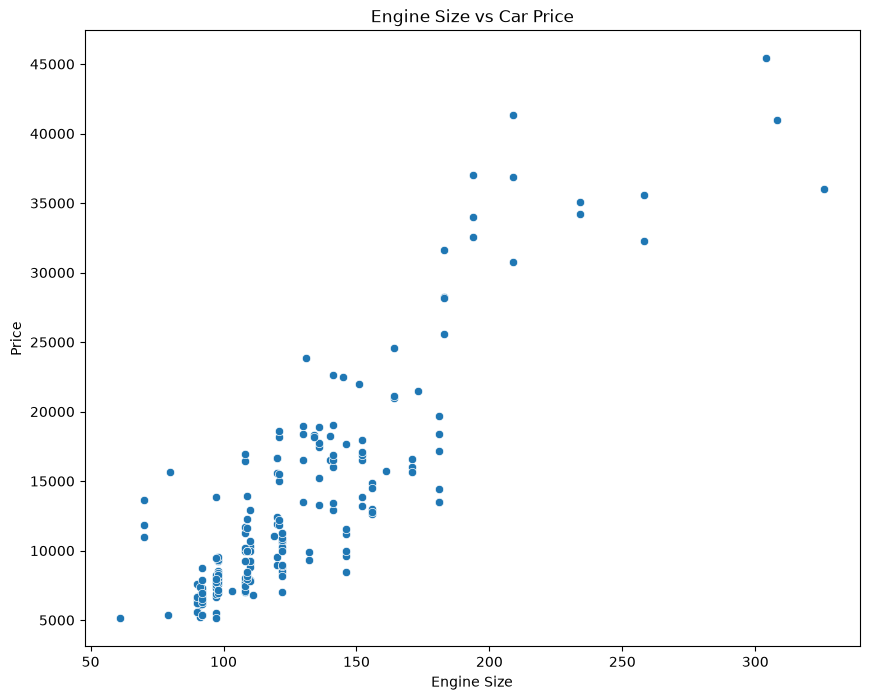

In [64]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df,
    x="Engine-size",
    y="Price"
)

plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()

# Explanation :
> A scatter plot puts each car as one dot.

- X-axis -> Engine Size
- Y-axis -> Price
- Each dot -> One car

> Impotant info:

    "As per Engine Size Changes, The Sale Price also Changes.If the dots generally move upward from left to right."
    
    Engine Size ↑
          ↓
    Price tends  ↑

# Categorical Columns :

In [65]:
Categorical_Columns=df.select_dtypes(include=["object"]).columns.tolist()
pd.DataFrame(Categorical_Columns,columns=["Categorical Columns"],index=range(1,len(Categorical_Columns)+1))

,Categorical Columns
1,Company-name
2,Fuel-type
3,Aspiration
4,Num-of-doors
5,Body-style
6,Drive-wheels
7,Engine-location
8,Engine-type
9,Num-of-cylinders
10,Fuel-system


# Separate X and y :

In [68]:
df_x = df.drop(columns=["Price"])    # Features
df_y = df["Price"]                   # Target variable

 # Encode Categorical Variables :

In [66]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

In [67]:
encoded_values = encoder.fit_transform(df[Categorical_Columns])

encoded_columns = encoder.get_feature_names_out(Categorical_Columns)
encoded_df = pd.DataFrame(encoded_values,columns=encoded_columns,index=df.index)

df = pd.concat([df.drop(columns=Categorical_Columns),encoded_df],axis=1)
df.head()

,Symboling,Normalized-Losses,Wheel-base,Length,Width,Height,Curb-weight,Engine-size,Bore,Stroke,...,Num-of-cylinders_three,Num-of-cylinders_twelve,Num-of-cylinders_two,Fuel-system_2bbl,Fuel-system_4bbl,Fuel-system_idi,Fuel-system_mfi,Fuel-system_mpfi,Fuel-system_spdi,Fuel-system_spfi
0,3,122.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,122.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,122.0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164.0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164.0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Explanation :
        "OneHotEncoding is used for Converting Categorical Datatype Columns to Numerical Datatype, Also because of categories do not have a natural numerical order."
> Importatnt Info :

* Converts categorical values into binary numerical columns.
* Creates names for the new encoded columns.
* Combines encoded columns with existing numerical columns.
* Removes the original categorical columns.
* Displays the transformed dataset.  

#   Train & Test Spliting :

In [69]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

> Important Info : 

* Train Data        : 80% Of data is used for "Training the Machine Learning (df_train_x,df_train_y)"
* Test Data         : 20% Of data is used for "Test the Model Performance(df_test_x,df_test_y)"
* 'df_x'            : Contains the input features.
* 'df_y'            : Contains the target variable, "Price".
* 'random_state=42' : Ensures that the same split is created each time.

In [70]:
df_train_x.head(3)              # Top 3 rows of training features

,Symboling,Normalized-Losses,Wheel-base,Length,Width,Height,Curb-weight,Engine-size,Bore,Stroke,...,Num-of-cylinders_three,Num-of-cylinders_twelve,Num-of-cylinders_two,Fuel-system_2bbl,Fuel-system_4bbl,Fuel-system_idi,Fuel-system_mfi,Fuel-system_mpfi,Fuel-system_spdi,Fuel-system_spfi
198,-1,95.0,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
38,0,85.0,96.5,175.4,65.2,54.1,2304,110,3.15,3.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,1,148.0,93.7,157.3,63.8,50.6,1989,90,2.97,3.23,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
df_train_y.head(3)              # Top 3 rows of training target variable

198    21485
38      8845
24      6692
Name: Price, dtype: int64

# Train Multiple Regression Models :

In [72]:
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)
dt_model = DecisionTreeRegressor(random_state=42)

# LinearRegression Model:

In [73]:
lr_model.fit(df_train_x,df_train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](64,)","[-127.57, -3.83, 197.65,...,1946.2 ,1172.55,2763.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](64,)","['Symboling','Normalized-Losses','Wheel-base',...,'Fuel-system_mpfi', 'Fuel-system_spdi','Fuel-system_spfi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1374
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,64
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(59)


In [74]:
lr_predictions = lr_model.predict(df_test_x)

In [75]:
mae = mean_absolute_error(df_test_y,lr_predictions)
mse = mean_squared_error(df_test_y,lr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(df_test_y,lr_predictions)
mape = mean_absolute_percentage_error(df_test_y,lr_predictions)

In [76]:
# Adjusted R-squared calculation :
adjusted_r2 = 1 - (1 - r2) * (len(df_test_y) - 1) / (len(df_test_y) - df_test_x.shape[1] - 1)

In [77]:
lr_metrics = {"Mean Absolute Error (MAE)": mae,
      "Mean Squared Error (MSE)": mse,
      "Root Mean Squared Error (RMSE)": rmse,
      "R-squared (R2)": r2,
      "Adjusted R-squared": adjusted_r2,
      "Mean Absolute Percentage Error (MAPE)": mape}

# Reporting the metrics

Report = pd.DataFrame(lr_metrics,index=["Metrics"]).T

Report

,Metrics
Mean Absolute Error (MAE),2.036546e+03
Mean Squared Error (MSE),1.092715e+07
Root Mean Squared Error (RMSE),3.305624e+03
R-squared (R2),9.106870e-01
Adjusted R-squared,1.148855e+00
Mean Absolute Percentage Error (MAPE),1.155258e-01


In [78]:
Accuracy = 100 - mape
print("\nAccuracy:", Accuracy)



Accuracy: 99.88447419677776


# RandomForestRegressor Model :

In [79]:
rf_model.fit(df_train_x,df_train_y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [80]:
rf_predictions = rf_model.predict(df_test_x)

In [81]:
rf_metrics = {"Mean Absolute Error (MAE)": mae,
      "Mean Squared Error (MSE)": mse,
      "Root Mean Squared Error (RMSE)": rmse,
      "R-squared (R2)": r2,
      "Adjusted R-squared": adjusted_r2,
      "Mean Absolute Percentage Error (MAPE)": mape}

# Reporting the metrics

Report = pd.DataFrame(rf_metrics,index=["Metrics"]).T

Report

,Metrics
Mean Absolute Error (MAE),2.036546e+03
Mean Squared Error (MSE),1.092715e+07
Root Mean Squared Error (RMSE),3.305624e+03
R-squared (R2),9.106870e-01
Adjusted R-squared,1.148855e+00
Mean Absolute Percentage Error (MAPE),1.155258e-01


In [82]:
mae = mean_absolute_error(df_test_y,rf_predictions)
mse = mean_squared_error(df_test_y,rf_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(df_test_y,rf_predictions)
mape = mean_absolute_percentage_error(df_test_y,rf_predictions)

In [83]:
# Adjusted R-squared calculation :
adjusted_r2 = 1 - (1 - r2) * (len(df_test_y) - 1) / (len(df_test_y) - df_test_x.shape[1] - 1)

In [84]:
rf_metrics = {"Mean Absolute Error (MAE)": mae,
      "Mean Squared Error (MSE)": mse,
      "Root Mean Squared Error (RMSE)": rmse,
      "R-squared (R2)": r2,
      "Adjusted R-squared": adjusted_r2,
      "Mean Absolute Percentage Error (MAPE)": mape}

# Reporting the metrics

Report = pd.DataFrame(rf_metrics,index=["Metrics"]).T

Report

,Metrics
Mean Absolute Error (MAE),1.869149e+03
Mean Squared Error (MSE),8.413698e+06
Root Mean Squared Error (RMSE),2.900638e+03
R-squared (R2),9.312307e-01
Adjusted R-squared,1.114615e+00
Mean Absolute Percentage Error (MAPE),1.043471e-01


In [85]:
accuracy = 100 - mape
print("\nAccuracy:", accuracy)



Accuracy: 99.89565286692367


# DecisionTreeRegressor Model :

In [86]:
dt_model.fit(df_train_x,df_train_y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [87]:
dt_predictions = dt_model.predict(df_test_x)

In [88]:
mae = mean_absolute_error(df_test_y,dt_predictions)
mse = mean_squared_error(df_test_y,dt_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(df_test_y,dt_predictions)
mape = mean_absolute_percentage_error(df_test_y,dt_predictions)

In [89]:
# Adjusted R-squared calculation :
adjusted_r2 = 1 - (1 - r2) * (len(df_test_y) - 1) / (len(df_test_y) - df_test_x.shape[1] - 1)

In [90]:
dt_metrics = {"Mean Absolute Error (MAE)": mae,
      "Mean Squared Error (MSE)": mse,
      "Root Mean Squared Error (RMSE)": rmse,
      "R-squared (R2)": r2,
      "Adjusted R-squared": adjusted_r2,
      "Mean Absolute Percentage Error (MAPE)": mape}

# Reporting the metrics

Report = pd.DataFrame(dt_metrics,index=["Metrics"]).T

Report

,Metrics
Mean Absolute Error (MAE),1.784463e+03
Mean Squared Error (MSE),6.745001e+06
Root Mean Squared Error (RMSE),2.597114e+03
R-squared (R2),9.448698e-01
Adjusted R-squared,1.091884e+00
Mean Absolute Percentage Error (MAPE),1.087935e-01


# Actual Vs Predicted Analysis :
(Scatter Plot Visual)

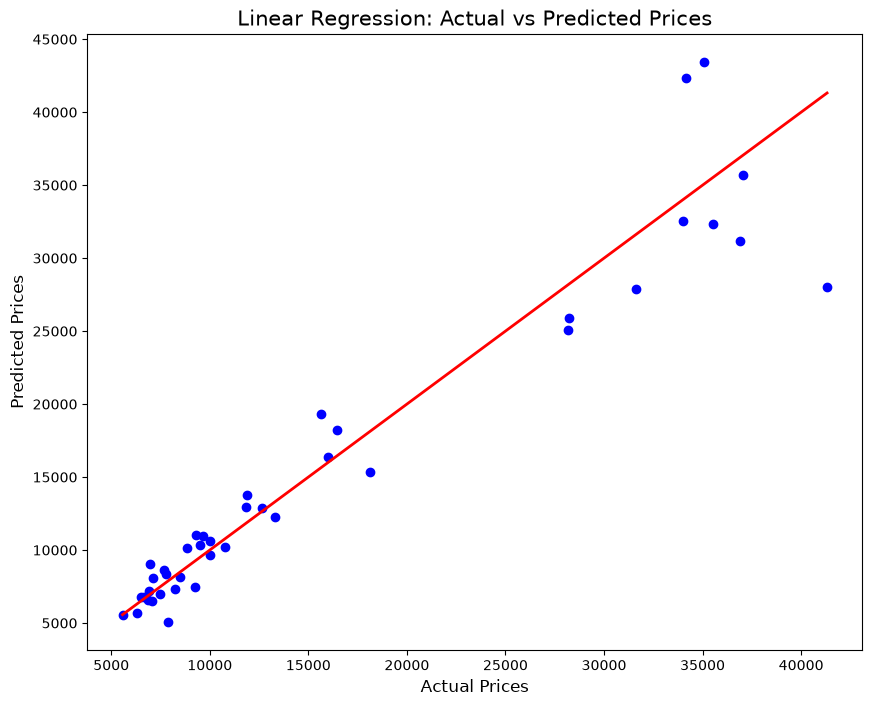

In [95]:
plt.figure(figsize=(10,8))
plt.scatter(df_test_y, lr_predictions, color='blue', label='Linear Regression')
plt.plot([df_test_y.min(), df_test_y.max()], [df_test_y.min(), df_test_y.max()],color='red', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Prices',fontsize=12)
plt.ylabel('Predicted Prices',fontsize=12)
plt.title('Linear Regression: Actual vs Predicted Prices',fontsize=15)
plt.show()

# Explanation :

* X-axis: Actual Price
* Y-axis: Predicted Price
* Blue dots: Each car in the test set
* Red line: “Perfect prediction line”

Importatnt info :

* If a dot is exactly on the red line, the prediction was perfect.
* If a dot is above the line, the model predicted a price higher than the real price.
* If a dot is below the line, the model predicted a price lower than the real price.

# Model Performance Comparison :

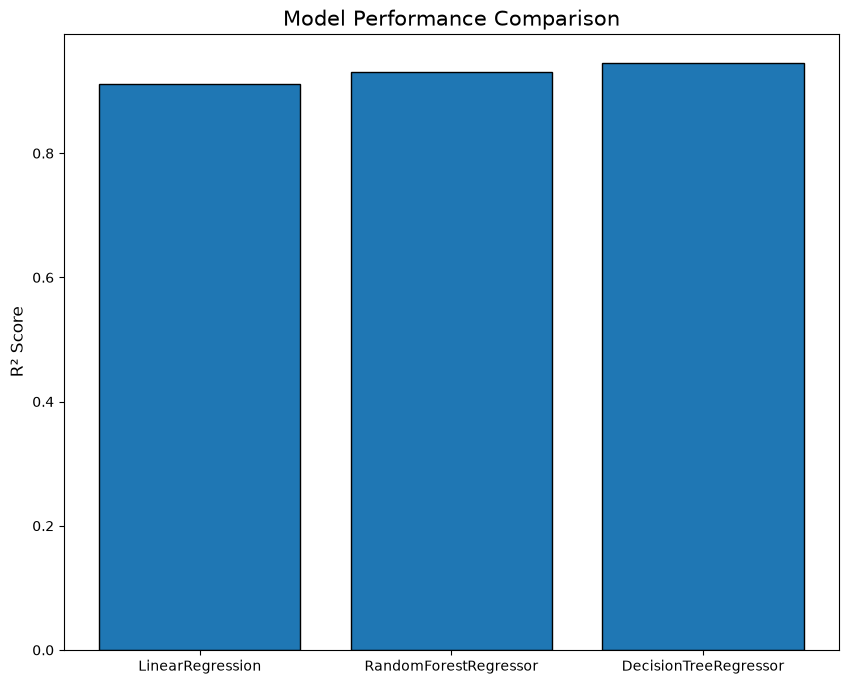

In [92]:
models = ["LinearRegression", "RandomForestRegressor", "DecisionTreeRegressor"]
scores = [r2_score(df_test_y, lr_predictions), r2_score(df_test_y, rf_predictions), r2_score(df_test_y, dt_predictions)]

plt.figure(figsize=(10,8))

plt.bar(models, scores,edgecolor='black')
plt.ylabel("R² Score",fontsize=12)
plt.title("Model Performance Comparison",fontsize=15)
plt.show()

# Explanation :

To compare the performance of the regression models, we evaluated each model using the R² score on the test dataset.  
R² measures how well the predicted car prices match the actual prices. A higher R² value indicates better model performance.

The comparison chart below shows the R² score for each model:
* Linear Regression        : 0.91
* Random Forest Regressor  : 0.93
* Decision Tree Regressor  : 0.94

The model with the highest R² score is considered the best-performing model for this dataset. This helps us select the model that provides the most reliable car price predictions.

# Model Comparison Table :

In [93]:
models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model
}

report = []

for model_name, model in models.items():
    
    predictions = model.predict(df_test_x)
    
    mae = mean_absolute_error(df_test_y, predictions)
    mse = mean_squared_error(df_test_y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(df_test_y, predictions)
    adjusted_r2 = 1 - (1 - r2) * (len(df_test_y) - 1) / (len(df_test_y) - df_test_x.shape[1] - 1)
    accuracy = 100 - mean_absolute_percentage_error(df_test_y, predictions)
    
    report.append({
        "Models": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2,
        "Accuracy": accuracy
    })
    
report_df = pd.DataFrame(report,index=range(1,len(report)+1))
report_df


,Models,MAE,MSE,RMSE,R²,Adjusted R²,Accuracy
1,Linear Regression,2036.546069,1.092715e+07,3305.624364,0.910687,1.148855,99.884474
2,Random Forest,1869.148902,8.413698e+06,2900.637590,0.931231,1.114615,99.895653
3,Decision Tree,1784.463415,6.745001e+06,2597.114032,0.944870,1.091884,99.891207


# Select Final Model & Save :

In [94]:
final_model = models[model_name]

# Refit on ALL data before shipping (tuned params are kept)
final_model.fit(df_x, df_y)

joblib.dump(final_model, "auto_price_model.joblib")
print(f"Saved '{model_name}' -> auto_price_model.joblib")

Saved 'Decision Tree' -> auto_price_model.joblib


# Conclusion

This project predicted car prices from specifications such as engine size, curb weight, horsepower, fuel type and brand. Three models were compared: Linear Regression, Decision Tree and Random Forest.

- **Key drivers:** Engine size, curb weight and horsepower have the strongest effect on price, and luxury brands cost much more than economy brands.
- **Best model:** Random Forest (tuned) gave the most reliable results, with a test R² of **___** and MAPE of **___ %**.
- **Limitations:** The dataset is small (201 rows) and old, so results can vary and may not match current prices.
- **Future work:** Collect more recent data, try XGBoost or LightGBM, and deploy the saved model in a Streamlit app.

The model gives reasonably accurate price estimates and can predict the price of a new car from its raw specifications.

# ***Thank You:)***